In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import anndata as ad
import scanpy as sc
import pertpy as pt
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from utils import scanpy_setup

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sc.set_figure_params(dpi=100, frameon=False, facecolor=None)

ryp2 is not installed. Install with pip install rpy2 to run tools with R support.

In [3]:
sc.logging.print_header()

scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.12.0 pandas==2.2.1 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


We'll demonstrate on Tahoe (small molecule) and Norman et al. (CRISPRa).

In [ ]:
adata = sc.read('./data/Tahoe_A549_only_full_genes.h5ad')
adata

In [ ]:
def _safe_mean(a, axis=0):
    return np.asarray(a.mean(axis=axis)).ravel()

def _rank_top_genes(scores, gene_names, n=100, absolute=True):
    scores = np.asarray(scores).ravel()
    order = np.argsort(-np.abs(scores)) if absolute else np.argsort(-scores)
    return pd.Index(gene_names[order[:n]])

def degs_by_distance(X_pert, X_ctrl, gene_names, n=100):
    mu_p = _safe_mean(X_pert, axis=0)
    mu_c = _safe_mean(X_ctrl, axis=0)
    var_p = np.var(X_pert, axis=0, ddof=1)
    var_c = np.var(X_ctrl, axis=0, ddof=1)

    t_stat, _ = ttest_ind(X_pert, X_ctrl, axis=0, equal_var=False, nan_policy="omit")
    t_stat = np.nan_to_num(t_stat, nan=0.0, posinf=0.0, neginf=0.0)

    ks_stat = np.array([
        ks_2samp(X_pert[:, i], X_ctrl[:, i], alternative="two-sided", mode="auto").statistic
        for i in range(X_pert.shape[1])
    ])

    var_p = np.maximum(var_p, eps)
    var_c = np.maximum(var_c, eps)
    kl_pc = 0.5 * (np.log(var_c / var_p) + (var_p + (mu_p - mu_c) ** 2) / var_c - 1.0)
    kl_cp = 0.5 * (np.log(var_p / var_c) + (var_c + (mu_p - mu_c) ** 2) / var_p - 1.0)
    kl_sym = np.nan_to_num(kl_pc + kl_cp, nan=0.0, posinf=0.0, neginf=0.0)

    euc = np.abs(mu_p - mu_c)
    mse = (mu_p - mu_c) ** 2
    mae = np.abs(mu_p - mu_c)

    return {
        "t_test": set(_rank_top_genes(t_stat, gene_names, n=n, absolute=True)),
        "ks_test": set(_rank_top_genes(ks_stat, gene_names, n=n, absolute=False)),
        "kl_div": set(_rank_top_genes(kl_sym, gene_names, n=n, absolute=False)),
        "euclidean": set(_rank_top_genes(euc, gene_names, n=n, absolute=False)),
        "mse": set(_rank_top_genes(mse, gene_names, n=n, absolute=False)),
        "mae": set(_rank_top_genes(mae, gene_names, n=n, absolute=False)),
    }

def jaccard(a, b):
    u = len(a | b)
    return len(a & b) / u if u else np.nan


order = ["mse", "euclidean", "mae", "ks_test", "t_test", "kl_div"]

In [ ]:
%%time
from scipy.stats import ttest_ind, ks_2samp

group_col = "perturbation"
control_label = "control"
top_n_drugs = 20
top_n_degs = 100
eps = 1e-12

if "log1p" not in adata.uns:
    sc.pp.log1p(adata)

X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
genes = adata.var_names.to_numpy()

top_drugs = (
    adata.obs[group_col]
    .value_counts()
    .loc[lambda s: s.index != control_label]
    .head(top_n_drugs)
    .index
    .tolist()
)

control_mask = (adata.obs[group_col].values == control_label)
X_ctrl = X[control_mask]

per_drug_mats = []
for drug in top_drugs:
    pert_mask = (adata.obs[group_col].values == drug)
    X_pert = X[pert_mask]
    if X_pert.shape[0] < 2:
        continue

    deg_sets = degs_by_distance(X_pert, X_ctrl, genes, n=top_n_degs)
    methods = list(deg_sets.keys())

    mat = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for m1 in methods:
        for m2 in methods:
            mat.loc[m1, m2] = jaccard(deg_sets[m1], deg_sets[m2])

    per_drug_mats.append(mat)

avg_jaccard = sum(per_drug_mats) / len(per_drug_mats)

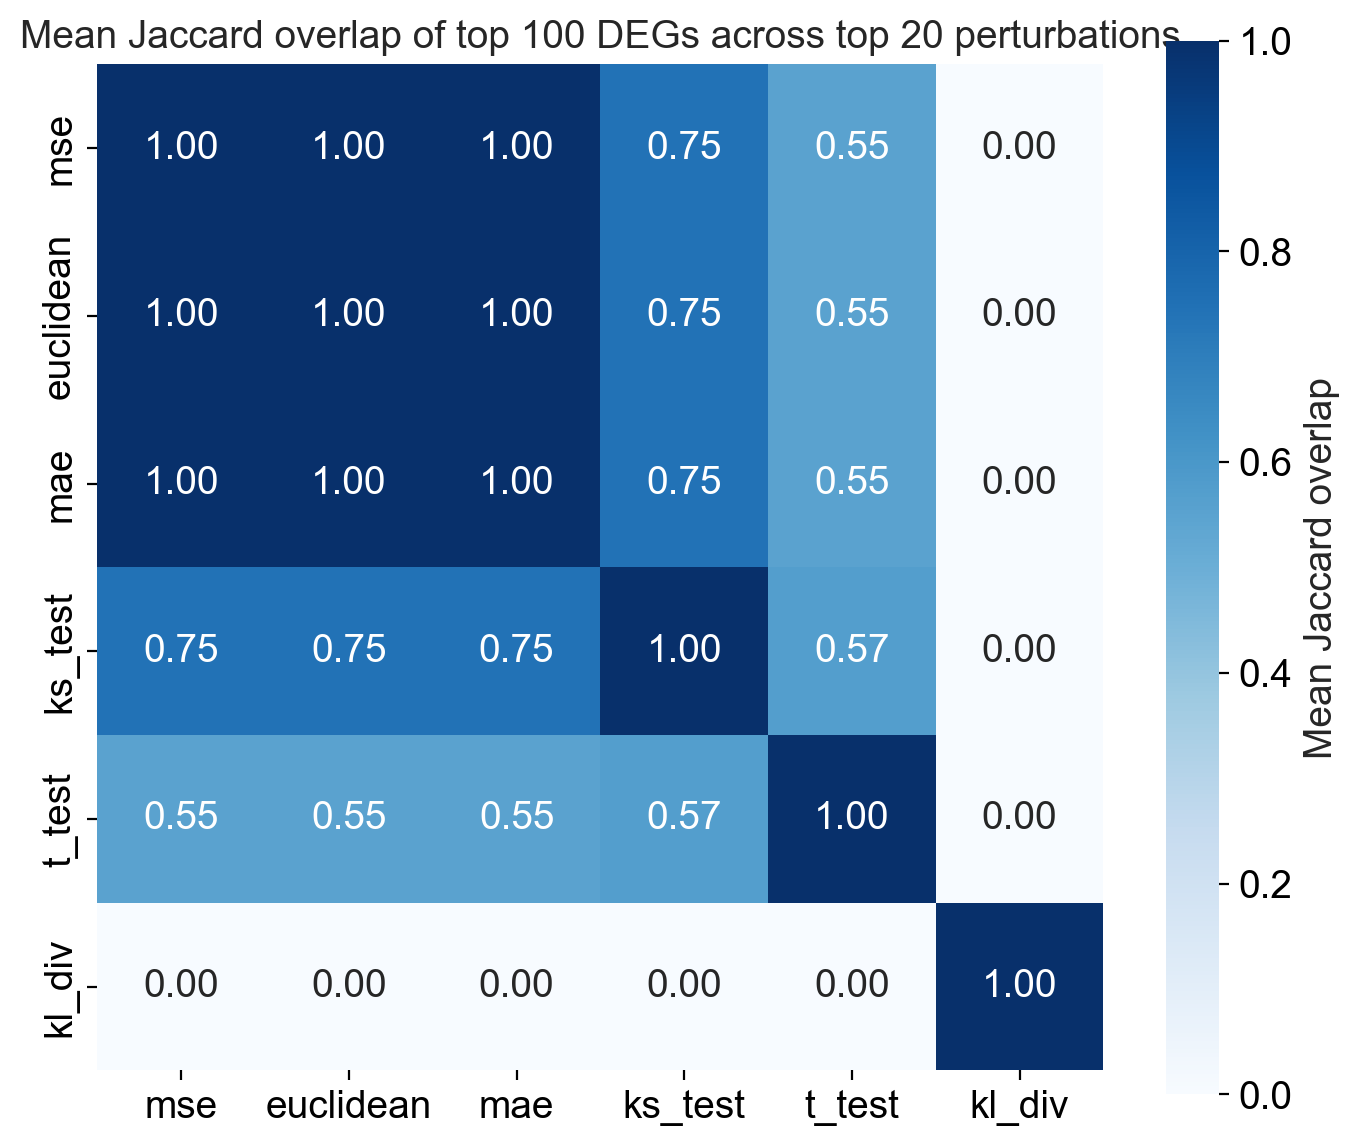

In [13]:
plt.figure(figsize=(7, 6))

avg_jaccard = avg_jaccard.loc[order, order]

sns.heatmap(
    avg_jaccard,
    annot=True,
    fmt=".2f",
    square=True,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean Jaccard overlap"},
)
plt.title(f"Mean Jaccard overlap of top {top_n_degs} DEGs across top {len(per_drug_mats)} perturbations")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures/rev_DEG_Tahoe.svg")
plt.show()

In [14]:
adata = pt.data.norman_2019()
adata

AnnData object with n_obs × n_vars = 111255 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', '

In [18]:
%%time
from scipy.stats import ttest_ind, ks_2samp

group_col = "perturbation_name"
control_label = "control"
top_n_drugs = 20
top_n_degs = 100
eps = 1e-12

if "log1p" not in adata.uns:
    sc.pp.log1p(adata)

X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
genes = adata.var_names.to_numpy()

top_drugs = (  # take top n drugs with most cells
    adata.obs[group_col]
    .value_counts()
    .loc[lambda s: s.index != control_label]
    .head(top_n_drugs)
    .index
    .tolist()
)

control_mask = (adata.obs[group_col].values == control_label)
X_ctrl = X[control_mask]

per_drug_mats = []
for drug in top_drugs:
    pert_mask = (adata.obs[group_col].values == drug)
    X_pert = X[pert_mask]
    if X_pert.shape[0] < 2:
        continue

    deg_sets = degs_by_distance(X_pert, X_ctrl, genes, n=top_n_degs)
    methods = list(deg_sets.keys())

    mat = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for m1 in methods:
        for m2 in methods:
            mat.loc[m1, m2] = jaccard(deg_sets[m1], deg_sets[m2])

    per_drug_mats.append(mat)

avg_jaccard = sum(per_drug_mats) / len(per_drug_mats)

CPU times: user 10min 11s, sys: 23 s, total: 10min 34s
Wall time: 10min 39s


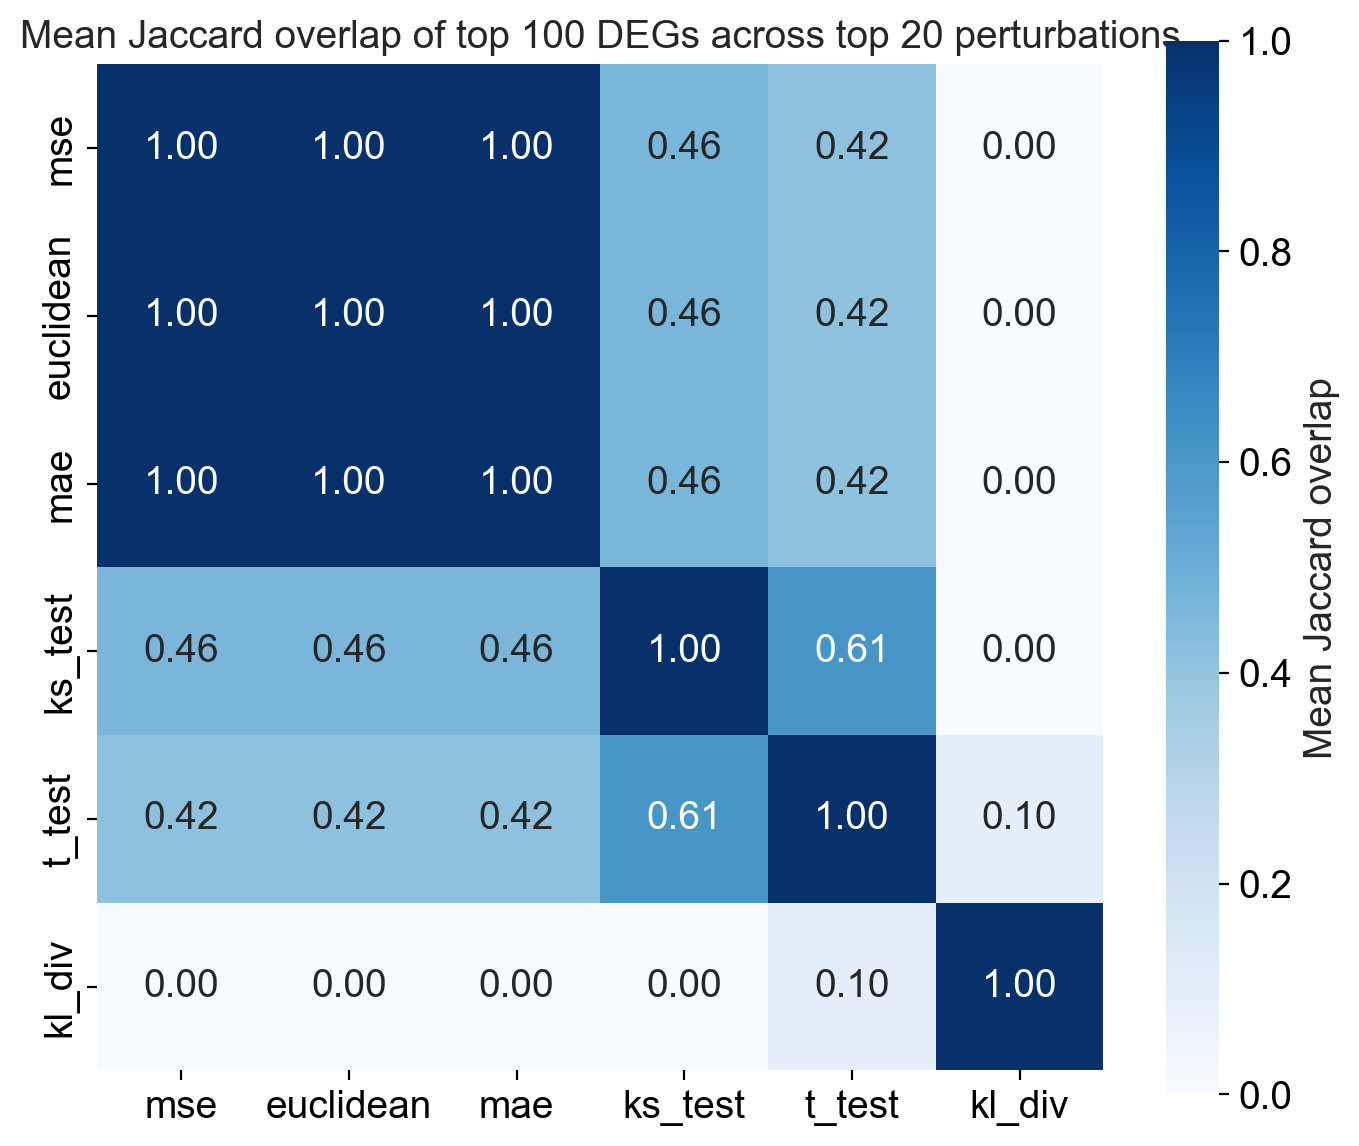

In [19]:
plt.figure(figsize=(7, 6))

order = ["mse", "euclidean", "mae", "ks_test", "t_test", "kl_div"]
avg_jaccard = avg_jaccard.loc[order, order]

sns.heatmap(
    avg_jaccard,
    annot=True,
    fmt=".2f",
    square=True,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean Jaccard overlap"},
)
plt.title(f"Mean Jaccard overlap of top {top_n_degs} DEGs across top {len(per_drug_mats)} perturbations")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures/rev_DEG_Norman.svg")
plt.show()